# Notes from PyTorch Official Documentation's 60 Minute Blitz

In [2]:
import torch
import numpy as np

### Tensor initialization

In [3]:
# Tensor initialization: array, numpy arrays, another tensor
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)

x_ones = torch.ones_like(x_data)
x_ones

tensor([[1, 1],
        [1, 1]])

In [4]:
# Can also be initialized with a shape
shape = (2, 3)
rand_tensor = torch.rand(shape) # [0, 1)
print(rand_tensor)

ones_tensor = torch.ones(shape) # uses torch.set_default_dtype; default is float32
print(ones_tensor)

tensor([[0.4216, 0.3692, 0.7666],
        [0.6241, 0.6345, 0.9763]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])


### Tensor Attributes

In [5]:
tensor = torch.rand(shape)
print(tensor.shape)
print(tensor.dtype)
print(tensor.device)

torch.Size([2, 3])
torch.float32
cpu


### Tensor Operations

In [6]:
# NumPy indexing/slicing
shape = (4, 4)
tensor = torch.ones(shape)
print(tensor[:, :2]) # all rows, first 2 cols

# np.concatenate() -> torch.cat()
# dim is zero-indexed, and is the dimension which will be expanding to a larger size
tensor = tensor[:, :2]
tensor[:, 1] = 0
print(torch.cat([tensor, tensor], dim=1))

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])
tensor([[1., 0., 1., 0.],
        [1., 0., 1., 0.],
        [1., 0., 1., 0.],
        [1., 0., 1., 0.]])


In [7]:
# Element-wise multiplication
torch.manual_seed(1)
t1 = torch.rand(shape)
t2 = torch.rand(shape)
print(t1)
print(t2)

print(t1 * t2 == t1.mul(t2)) # both element-wise
t1.mul(t2)

tensor([[0.7576, 0.2793, 0.4031, 0.7347],
        [0.0293, 0.7999, 0.3971, 0.7544],
        [0.5695, 0.4388, 0.6387, 0.5247],
        [0.6826, 0.3051, 0.4635, 0.4550]])
tensor([[0.5725, 0.4980, 0.9371, 0.6556],
        [0.3138, 0.1980, 0.4162, 0.2843],
        [0.3398, 0.5239, 0.7981, 0.7718],
        [0.0112, 0.8100, 0.6397, 0.9743]])
tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])


tensor([[0.4337, 0.1391, 0.3777, 0.4817],
        [0.0092, 0.1584, 0.1653, 0.2145],
        [0.1935, 0.2299, 0.5097, 0.4049],
        [0.0077, 0.2472, 0.2965, 0.4433]])

In [8]:
# Matrix multiplication
print(t1 @ t2)
print(t1.matmul(t2))

tensor([[0.6666, 1.2389, 1.6179, 1.6030],
        [0.4112, 0.9921, 1.1598, 1.2881],
        [0.6866, 1.1301, 1.5616, 1.5022],
        [0.6491, 1.0118, 1.4277, 1.3353]])
tensor([[0.6666, 1.2389, 1.6179, 1.6030],
        [0.4112, 0.9921, 1.1598, 1.2881],
        [0.6866, 1.1301, 1.5616, 1.5022],
        [0.6491, 1.0118, 1.4277, 1.3353]])


Any operation with a trailing '_' is in-place.

### `torch.autograd`

Neural networks are a collection of functions that are executed on input data. The functions are defined by parameters, being weights and biases, which are stord in tensors.

Training occurs in 2 steps:
1. Forward propagation - NN makes its best guess about the correct output and runs input data through its functions to make the guess
2. Backward propagation - NN adjusts its parameters proportionate to the error in its guess. It works with the output and takes the derivatives of the error w.r.t. the parameters of the functions, optimizing parameters through gradient descent.

![](images/2026-01-26-14-30-51.png)
- The chain rule is repeatedly used to evaluate the change in loss function over change in some parameter $w$
- The superscripts are used to denote distinct steps of the simplified neural network; not exponents

For any specific layer $l$ in the neural network, $z^{(l)} = \sum_i w_i^{(l)} a_i^{(l-1)} + b^{(l)}$.

Then, after computing $z^{(l)}$, an activation function $\sigma(z^{(l)})$ is used to obtain $a^{(l)}$, which is what gets passed to the next layer.

In [9]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1, 3, 64, 64) # 1 batch size, 3 channels (RGB), 64 x 64 (height, width) order
labels = torch.rand(1, 1000)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/jerry/Downloads/torch-cache/hub/checkpoints/resnet18-f37072fd.pth
100.0%


In [10]:
# Forward pass -> predicts using inputs + compute loss
prediction = model(data) # torch.nn has __call__ defined, so we can use it like a function
loss = (prediction - labels).sum()

# Backward pass -> compute gradients of loss wrt learnable parameters
# Usually want to clear gradients using optim.zero_grad() because for multiple iterations gradients are additive instead of overwriting
loss.backward() # Autograd calculates and stores gradients for each model parameter in that parameter's .grad attribute

In [11]:
# Update model parameters -> uses param.grad to update param.data
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
optim.step() # gradient descent step

### Neural Networks (`torch.nn`)

A typical training process for neural networks is:
1. Define the neural network which has some learnable parameters (weights)
2. Iterate over all of the observations in the training dataset
3. Process input, compute the loss, and propagate gradients into parameter
4. Update the weights of the network (optimizer step)

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, input):
        # Output tensor size is (Input size - Kernel size + 2*Padding) / Stride + 1
        # Default is (stride=1, padding=0)
        c1 = F.relu(self.conv1(input)) # F.relu() essentially applies max(0, x) to each element

        # Subsampling layer
        # Slides 2x2 window and keeps only the maximum value
        s2 = F.max_pool2d(c1, (2, 2))

        c3 = F.relu(self.conv2(s2))

        s4 = F.max_pool2d(c3, 2)
        s4 = torch.flatten(s4, 1)

        f5 = F.relu(self.fc1(s4))

        f6 = F.relu(self.fc2(f5))

        output = self.fc3(f6)
        return output
    
net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [13]:
params = list(net.parameters())
print(len(params))
print(params[0].size())

10
torch.Size([6, 1, 5, 5])


In [14]:
input = torch.randn(1, 1, 32, 32)
out = net(input)
print(out)

tensor([[-0.0752, -0.1290,  0.0069,  0.1153, -0.0662, -0.0115,  0.0070, -0.0682,
         -0.0487, -0.0736]], grad_fn=<AddmmBackward0>)


In [ ]:
net.zero_grad()
out.backward(torch.randn(1, 10)) # .backward should be called on a scalar tensor

### Loss Function

In [27]:
output = net(input)
target = torch.randn(10)
target = target.view(1, -1)
criterion = nn.MSELoss()

loss = criterion(output, target)
print(loss)

tensor(1.0615, grad_fn=<MseLossBackward0>)


In [29]:
print(loss.grad_fn)
print(loss.grad_fn.next_functions[0][0])
print(loss.grad_fn.next_functions[0][0].next_functions[0][0])

### Back Propagation

In [30]:
net.zero_grad()
print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)

loss.backward()

print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([ 0.0017,  0.0101,  0.0027, -0.0141, -0.0012,  0.0142])


### Updating Weights

In [ ]:
learning_rate = 0.01
for f in net.parameters():
    f.data.sub_(f.grad.data * learning_rate) # gradient points to toward increasing loss; move opposite so subtract

tensor([[[[-0.1580, -0.1427,  0.1986, -0.0516, -0.1616],
          [ 0.0476, -0.0331,  0.1053,  0.0019, -0.1428],
          [-0.0888, -0.1652,  0.1469, -0.1426, -0.1541],
          [ 0.0758, -0.0526, -0.1020,  0.1817,  0.1056],
          [-0.1175,  0.0512,  0.0590, -0.1436, -0.0502]]],


        [[[-0.1604, -0.0190,  0.0607,  0.0643,  0.1611],
          [-0.0654,  0.1845,  0.1571,  0.1388,  0.1895],
          [-0.1573, -0.1420, -0.0989, -0.0677, -0.0964],
          [ 0.0576, -0.1212, -0.1087, -0.1089, -0.1770],
          [-0.1079,  0.1120,  0.0930,  0.0072, -0.0492]]],


        [[[-0.1935, -0.1872, -0.0184,  0.0838, -0.1455],
          [-0.0306,  0.1026,  0.0116, -0.1191,  0.1087],
          [-0.0697,  0.0662, -0.1027, -0.1332,  0.0995],
          [-0.0526,  0.0937, -0.0083,  0.0416,  0.0875],
          [ 0.1421,  0.0007, -0.0222, -0.0134, -0.1308]]],


        [[[-0.1812, -0.1541,  0.0751,  0.0404, -0.0433],
          [ 0.1163,  0.0854, -0.0054,  0.0908, -0.1425],
          [ 0.1751,

In [35]:
import torch.optim as optim

optimizer = optim.SGD(net.parameters(), lr=learning_rate)
optimizer.zero_grad()
output = net(input)
loss = criterion(output, target) # callable object
loss.backward()
optimizer.step()

### Training a Classifier

In [36]:
import torch
import torchvision
import torchvision.transforms as transforms

In [37]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

0.0%

100.0%


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


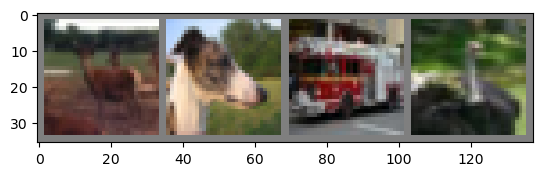

deer  dog   truck bird 


In [39]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120) # fully-connected; 
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [41]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [44]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # fills in .grad on each parameter object, which is stored in net.conv1.weight.grad, etc.
        optimizer.step() # already has references to those same parameters, which is why it can update accordingly

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 0.909
[1,  4000] loss: 0.940
[1,  6000] loss: 0.947
[1,  8000] loss: 0.935
[1, 10000] loss: 0.960
[1, 12000] loss: 0.948
[2,  2000] loss: 0.850
[2,  4000] loss: 0.890
[2,  6000] loss: 0.914
[2,  8000] loss: 0.909
[2, 10000] loss: 0.907
[2, 12000] loss: 0.918
Finished Training


In [45]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

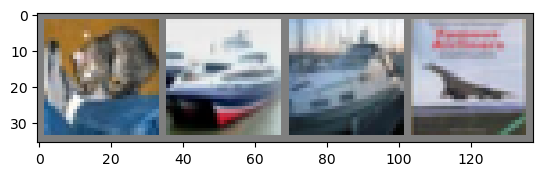

GroundTruth:  cat   ship  ship  plane


In [46]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [47]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [49]:
outputs = net(images)
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  frog  car   plane plane


In [50]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 63 %


In [51]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 73.6 %
Accuracy for class: car   is 77.0 %
Accuracy for class: bird  is 51.7 %
Accuracy for class: cat   is 40.6 %
Accuracy for class: deer  is 63.0 %
Accuracy for class: dog   is 52.4 %
Accuracy for class: frog  is 71.6 %
Accuracy for class: horse is 63.4 %
Accuracy for class: ship  is 72.5 %
Accuracy for class: truck is 66.3 %
